# 다중클래스분류_calback사용해 과적합_막고_최고성능모델_저장하기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data=pd.read_csv("./data/winequality-white.csv", sep=";")

In [3]:
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


<Axes: >

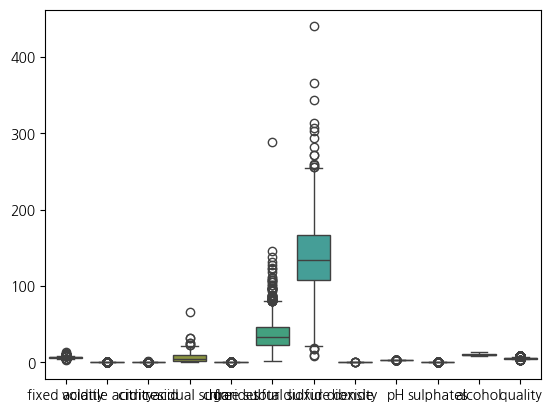

In [5]:
sns.boxplot(data)

In [6]:
data['quality'].value_counts()

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

In [7]:
data['quality'].nunique()

7

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [9]:
X=data.drop('quality', axis=1)
y=data['quality']

In [10]:
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9
...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [11]:
y

0       6
1       6
2       6
3       6
4       6
       ..
4893    6
4894    5
4895    6
4896    7
4897    6
Name: quality, Length: 4898, dtype: int64

In [12]:
y=pd.get_dummies(y)
y

,3,4,5,6,7,8,9
0,False,False,False,True,False,False,False
1,False,False,False,True,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,True,False,False,False
4,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
4893,False,False,False,True,False,False,False
4894,False,False,True,False,False,False,False
4895,False,False,False,True,False,False,False
4896,False,False,False,False,True,False,False


In [13]:
X_train, X_valid, y_train, y_valid=train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test= train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [14]:
X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3940,6.9,0.40,0.37,8.90,0.053,36.0,148.0,0.99600,3.16,0.50,9.3
3905,6.5,0.33,0.30,3.80,0.036,34.0,88.0,0.99028,3.25,0.63,12.5
53,6.4,0.18,0.35,1.00,0.045,39.0,108.0,0.99110,3.31,0.35,10.9
2576,6.5,0.27,0.40,10.00,0.039,74.0,227.0,0.99582,3.18,0.50,9.4
1970,8.3,0.49,0.43,2.50,0.036,32.0,116.0,0.99440,3.23,0.47,10.7
...,...,...,...,...,...,...,...,...,...,...,...
2609,7.1,0.20,0.30,0.90,0.019,4.0,28.0,0.98931,3.20,0.36,12.0
2530,5.8,0.30,0.12,1.60,0.036,57.0,163.0,0.99239,3.38,0.59,10.5
1231,7.9,0.41,0.37,4.50,0.030,40.0,114.0,0.99200,3.17,0.54,12.4
3948,5.7,0.14,0.30,5.40,0.045,26.0,105.0,0.99469,3.32,0.45,9.3


In [15]:
rs=RobustScaler()
train_temp=rs.fit_transform(X_train)
valid_temp=rs.transform(X_valid)
test_temp=rs.transform(X_test)
rs_X_train=pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
rs_X_valid=pd.DataFrame(valid_temp, columns=X_valid.columns, index=X_valid.index)
rs_X_test=pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [16]:
rs_X_train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3940,0.090909,1.272727,0.416667,0.451220,0.714286,0.090909,0.216667,0.507205,-0.05,0.142857,-0.578947
3905,-0.272727,0.636364,-0.166667,-0.170732,-0.500000,0.000000,-0.783333,-0.811527,0.40,1.071429,1.105263
53,-0.363636,-0.727273,0.250000,-0.512195,0.142857,0.227273,-0.450000,-0.622478,0.70,-0.928571,0.263158
2576,-0.272727,0.090909,0.666667,0.585366,-0.285714,1.818182,1.533333,0.465706,0.05,0.142857,-0.526316
1970,1.363636,2.090909,0.916667,-0.329268,-0.500000,-0.090909,-0.316667,0.138329,0.30,-0.071429,0.157895
...,...,...,...,...,...,...,...,...,...,...,...
2609,0.272727,-0.545455,-0.166667,-0.524390,-1.714286,-1.363636,-1.783333,-1.035159,0.15,-0.857143,0.842105
2530,-0.909091,0.363636,-1.666667,-0.439024,-0.500000,1.045455,0.466667,-0.325072,1.05,0.785714,0.052632
1231,1.000000,1.363636,0.416667,-0.085366,-0.928571,0.272727,-0.350000,-0.414986,0.00,0.428571,1.052632
3948,-1.000000,-1.090909,-0.166667,0.024390,0.142857,-0.363636,-0.500000,0.205187,0.75,-0.214286,-0.578947


In [17]:
y_train

,3,4,5,6,7,8,9
3940,False,False,True,False,False,False,False
3905,False,False,False,False,True,False,False
53,False,False,False,True,False,False,False
2576,False,False,True,False,False,False,False
1970,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...
2609,False,False,False,True,False,False,False
2530,False,False,False,True,False,False,False
1231,False,False,False,False,True,False,False
3948,False,False,True,False,False,False,False


# 모델을 최고 성능에서 저장하고 중지하기

In [26]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [27]:
n_class=y_train.shape[1]
model=Sequential()
model.add(Input(shape=(rs_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(7, activation='softmax'))

In [28]:
import os

Epoch 1/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2695 - loss: 1.7309 - val_accuracy: 0.4939 - val_loss: 1.2908
Epoch 2/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5026 - loss: 1.2345 - val_accuracy: 0.5306 - val_loss: 1.1857
Epoch 3/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5389 - loss: 1.1130 - val_accuracy: 0.5367 - val_loss: 1.1425
Epoch 4/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5606 - loss: 1.0811 - val_accuracy: 0.5510 - val_loss: 1.1249
Epoch 5/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5682 - loss: 1.0463 - val_accuracy: 0.5449 - val_loss: 1.1147
Epoch 6/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5599 - loss: 1.0283 - val_accuracy: 0.5469 - val_loss: 1.1037
Epoch 7/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5542 - loss: 1.0500 - val_accuracy: 0.5561 - val_loss: 1.0966
Epoch 8/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5547 - loss: 1.0449 - val_accuracy: 0

92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6636 - loss: 0.8240 - val_accuracy: 0.5694 - val_loss: 1.1040
Epoch 52/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6467 - loss: 0.8049 - val_accuracy: 0.5796 - val_loss: 1.1022
Epoch 53/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6737 - loss: 0.8173 - val_accuracy: 0.5755 - val_loss: 1.0847
Epoch 54/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6761 - loss: 0.7882 - val_accuracy: 0.5643 - val_loss: 1.1143
Epoch 55/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6782 - loss: 0.7906 - val_accuracy: 0.5765 - val_loss: 1.1034
Epoch 56/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6859 - loss: 0.7726 - val_accuracy: 0.5745 - val_loss: 1.0959
Epoch 57/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6812 - loss: 0.7905 - val_accuracy: 0.5806 - val_loss: 1.0999
Epoch 58/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6936 - loss: 0.7658 - val_accuracy: 0.5745 -

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7451 - loss: 0.6294 - val_accuracy: 0.5837 - val_loss: 1.2383
Epoch 102/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7309 - loss: 0.6489 - val_accuracy: 0.5806 - val_loss: 1.2367
Epoch 103/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ -0s -3987us/step - accuracy: 0.7480 - loss: 0.6357 - val_accuracy: 0.5816 - val_loss: 1.2672
Epoch 104/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7480 - loss: 0.6272 - val_accuracy: 0.5796 - val_loss: 1.2587
Epoch 105/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7375 - loss: 0.6476 - val_accuracy: 0.5898 - val_loss: 1.2671
Epoch 106/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7426 - loss: 0.6276 - val_accuracy: 0.5745 - val_loss: 1.2819
Epoch 107/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7498 - loss: 0.6321 - val_accuracy: 0.5786 - val_loss: 1.2772
Epoch 108/1000
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7623 - loss: 0.6196 - val_accura

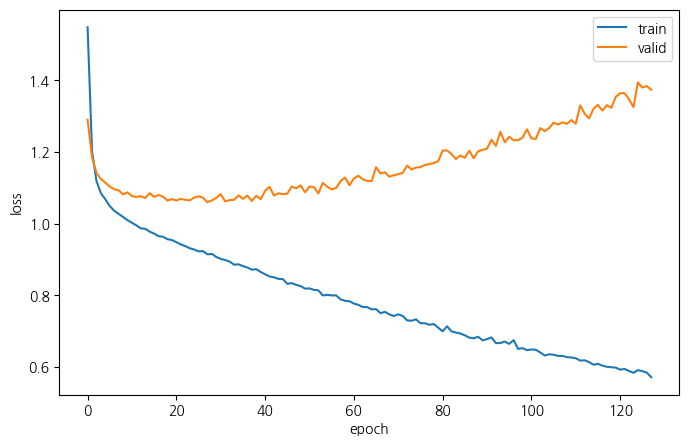

In [29]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop=EarlyStopping(patience=100)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동으로 생성
filepath = "./model/witewine_loss_{val_loss:.4f}_{epoch:04d}.keras"
model_save = ModelCheckpoint(filepath=filepath,save_best_only=True)
history=model.fit(rs_X_train, y_train, epochs=1000, batch_size=32, validation_data=(rs_X_valid, y_valid), callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train','valid'])
plt.show()

In [31]:
for i in history.history:
    print(i)

accuracy
loss
val_accuracy
val_loss


# 데이터 증폭 후 분석
* 데이터 증폭 + 스케일러 사용시
* 데이터 증폭 후 스케일러로 스케일링

In [40]:
from imblearn.over_sampling import SMOTE

In [43]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [47]:
X=data.drop('quality', axis=1)
y=data['quality']

In [48]:
X_train, X_valid, y_train, y_valid=train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_valid, X_test, y_valid, y_test= train_test_split(X_valid, y_valid, test_size=0.5, stratify=y_valid, random_state=42)

In [49]:
smt=SMOTE(k_neighbors=2, random_state=42)
smt_X_train, smt_y_train=smt.fit_resample(X_train, y_train)
smt_X_train=pd.DataFrame(smt_X_train, columns=X_train.columns)
smt_y_train=pd.Series(smt_y_train)

/home/fintech/miniforge3/envs/tf/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [53]:
rs=RobustScaler()
train_temp=rs.fit_transform(X_train)
valid_temp=rs.transform(X_valid)
test_temp=rs.transform(X_test)
rs_X_train=pd.DataFrame(train_temp, columns=X_train.columns, index=X_train.index)
rs_X_valid=pd.DataFrame(valid_temp, columns=X_valid.columns, index=X_valid.index)
rs_X_test=pd.DataFrame(test_temp, columns=X_test.columns, index=X_test.index)

In [54]:
ot_smt_y_train=pd.get_dummies(smt_y_train)
ot_smt_y_train

,3,4,5,6,7,8,9
0,False,False,False,False,True,False,False
1,False,False,True,False,False,False,False
2,False,False,False,True,False,False,False
3,False,False,False,False,True,False,False
4,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
9221,False,False,False,False,False,False,True
9222,False,False,False,False,False,False,True
9223,False,False,False,False,False,False,True
9224,False,False,False,False,False,False,True


In [55]:
y_valid=pd.get_dummies(y_valid)

In [56]:
y_test=pd.get_dummies(y_test)

In [57]:
y_test

,3,4,5,6,7,8,9
2613,False,False,True,False,False,False,False
2361,False,False,True,False,False,False,False
4245,False,False,True,False,False,False,False
3947,False,False,False,False,True,False,False
3799,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
4502,False,False,False,True,False,False,False
3148,False,False,False,True,False,False,False
1562,False,False,False,False,True,False,False
37,False,False,False,True,False,False,False


In [58]:
smt_X_train.shape[1]

11

In [61]:
n_class=ot_smt_y_train.shape[1]
model=Sequential()
model.add(Input(shape=(smt_X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(7, activation='softmax'))
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,495 (13.65 KB)

 Trainable params: 3,495 (13.65 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
early_stop=EarlyStopping(patience=1000)
os.makedirs("./model", exist_ok=True) # 디렉토리 자동으로 생성
filepath = "./model/witewine_loss_{val_loss:.4f}_{epoch:04d}.keras"
model_save = ModelCheckpoint(filepath=filepath,save_best_only=True)
history=model.fit(rs_X_train, y_train, epochs=10000, batch_size=32, validation_data=(rs_X_valid, y_valid), callbacks=[early_stop, model_save])
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['train','valid'])
plt.show()

# 저장된 best 모델 불러와서 사용하기

In [62]:
rs_X_test

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
2613,-0.2,0.909091,1.702128,0.63750,0.500000,-0.217391,0.083333,0.587699,-0.578947,-0.500000,-0.526316
2361,1.4,-0.090909,1.191489,-0.15625,0.500000,-0.869565,-0.550000,0.350797,0.526316,0.785714,-0.368421
4245,0.8,0.818182,1.276596,1.03750,-0.428571,0.347826,-0.316667,1.029613,-0.736842,0.214286,-0.631579
3947,-0.7,0.363636,0.000000,-0.35000,-0.071429,0.304348,0.116667,-0.952164,0.684211,-0.214286,1.210526
3799,0.2,0.363636,-0.340426,-0.35000,-0.071429,-0.565217,0.700000,-0.464692,0.105263,0.714286,0.526316
...,...,...,...,...,...,...,...,...,...,...,...
4502,0.3,-0.090909,-0.085106,-0.33750,0.500000,-0.086957,0.350000,-0.523918,-0.210526,0.285714,0.526316
3148,-0.6,-0.272727,0.340426,1.52500,-0.285714,0.130435,-0.083333,1.312073,0.263158,-0.285714,-0.842105
1562,0.3,0.727273,1.446809,-0.43750,-1.142857,-0.347826,-0.150000,-0.842825,0.631579,-1.000000,0.947368
37,0.2,0.636364,0.000000,-0.47500,0.714286,0.173913,0.050000,-0.706150,-0.263158,-1.357143,0.421053


In [63]:
y_test

,3,4,5,6,7,8,9
2613,False,False,True,False,False,False,False
2361,False,False,True,False,False,False,False
4245,False,False,True,False,False,False,False
3947,False,False,False,False,True,False,False
3799,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...
4502,False,False,False,True,False,False,False
3148,False,False,False,True,False,False,False
1562,False,False,False,False,True,False,False
37,False,False,False,True,False,False,False


In [ ]:
from keras.models import load_model
best_model=load_model("./model/witewine_0021_1.0616.keras")
wine_pred=best_model.predict(rs_X_test)
wine_pred=pd.DataFrame(wine_pred, columns=)